# Phase 4 — HGNN Model (Single Client Baseline)
**Input:** `Dataset/Processed/graph_data.pt` (output from Phase 3)  
**Output:** `Dataset/Processed/model_baseline.pt` + evaluation metrics  

**What this notebook does:**
1. Load the HeteroData graph from Phase 3
2. Add reverse edges so HANConv can update all node types
3. Define train/test masks on User nodes
4. Build the HANConv-based HGNN classifier
5. Train for binary classification (Normal vs Anomaly)
6. Evaluate: Accuracy, Precision, Recall, F1-score, Confusion Matrix
7. Plot training loss curve
8. Save the trained model

## Cell 1 — Imports & Load Graph

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from torch_geometric.nn import HANConv
import os

# update these paths to match your local setup
GRAPH_PATH = os.path.expanduser("~/Downloads/federated-hgnn-anomaly-detection/Dataset/Processed/graph_data.pt")
MODEL_PATH = os.path.expanduser("~/Downloads/federated-hgnn-anomaly-detection/Dataset/Processed/model_baseline.pt")

graph = torch.load(GRAPH_PATH, weights_only=False)

print("Graph loaded successfully.")
print(graph)
print(f"\nUser node features: {graph['user'].x.shape}")
print(f"User labels:        {graph['user'].y.tolist()}  (0=Normal, 1=Anomaly)")

Graph loaded successfully.
HeteroData(
  user={
    x=[3, 8],
    y=[3],
  },
  ip={ x=[14, 1] },
  service={ x=[22, 1] },
  (user, accesses, ip)={ edge_index=[2, 1000] },
  (user, calls, service)={ edge_index=[2, 1000] }
)

User node features: torch.Size([3, 8])
User labels:        [1, 1, 0]  (0=Normal, 1=Anomaly)


## Cell 2 — Add Reverse Edges
HANConv only produces embeddings for nodes that are destinations of at least one edge.  
Since `user` is always source (user->ip, user->service), we add reverse edges  
so that `user` also receives messages and keeps its embedding in the forward pass.

In [2]:
if ('ip', 'accessed_by', 'user') not in graph.edge_types:
    graph['ip', 'accessed_by', 'user'].edge_index = graph['user', 'accesses', 'ip'].edge_index.flip(0)
    graph['service', 'called_by', 'user'].edge_index = graph['user', 'calls', 'service'].edge_index.flip(0)
    print("Reverse edges added.")
else:
    print("Reverse edges already present.")

print("\nUpdated graph:")
print("  Node types:", graph.node_types)
print("  Edge types:", graph.edge_types)

Reverse edges added.

Updated graph:
  Node types: ['user', 'ip', 'service']
  Edge types: [('user', 'accesses', 'ip'), ('user', 'calls', 'service'), ('ip', 'accessed_by', 'user'), ('service', 'called_by', 'user')]


## Cell 3 — Define Train / Test Masks
3 user nodes total. Leave-one-out split:  
- Train: [0] benjamin, [1] bert-jan  
- Test:  [2] Unknown

In [3]:
train_mask = torch.tensor([True,  True,  False], dtype=torch.bool)
test_mask = torch.tensor([False, False, True],  dtype=torch.bool)

graph['user'].train_mask = train_mask
graph['user'].test_mask = test_mask

print("Train/Test split on User nodes:")
print(f"  Training nodes : {train_mask.sum().item()} (indices {train_mask.nonzero().flatten().tolist()})")
print(f"  Test nodes     : {test_mask.sum().item()}  (index  {test_mask.nonzero().flatten().tolist()})")
print(f"  Train labels   : {graph['user'].y[train_mask].tolist()}")
print(f"  Test labels    : {graph['user'].y[test_mask].tolist()}")

Train/Test split on User nodes:
  Training nodes : 2 (indices [0, 1])
  Test nodes     : 1  (index  [2])
  Train labels   : [1, 1]
  Test labels    : [0]


## Cell 4 — Define the HGNN Model
Architecture:
- Linear projection layers: map all node types to `hidden_channels` before HANConv
- HANConv layer: heterogeneous attention message passing
- Fallback: if HANConv drops a source-only node type, restore from pre-conv projection
- Classifier: Linear -> 2 output classes (Normal / Anomaly)

In [4]:
class FederatedHGNN(nn.Module):
    def __init__(self, in_channels_dict, hidden_channels, out_channels, metadata):
        super(FederatedHGNN, self).__init__()

        # Project each node type to the same hidden dimension before HANConv
        self.user_proj = nn.Linear(in_channels_dict['user'], hidden_channels)
        self.ip_proj = nn.Linear(in_channels_dict['ip'], hidden_channels)
        self.service_proj = nn.Linear(in_channels_dict['service'], hidden_channels)

        # HANConv: heterogeneous graph attention convolution
        self.han = HANConv(
            in_channels=hidden_channels,
            out_channels=hidden_channels,
            metadata=metadata,
            heads=4,
            dropout=0.3,
        )

        # Final classifier applied to user node embeddings only
        self.classifier = nn.Linear(hidden_channels, out_channels)

    def forward(self, x_dict, edge_index_dict):
        # Step 1: project all node types to hidden_channels
        h = {
            'user': F.elu(self.user_proj(x_dict['user'])),
            'ip': F.elu(self.ip_proj(x_dict['ip'])),
            'service': F.elu(self.service_proj(x_dict['service'])),
        }

        # Step 2: HANConv message passing
        h_out = self.han(h, edge_index_dict)

        # Step 3: restore any node type HANConv dropped (source-only nodes)
        for key in h:
            if key not in h_out or h_out[key] is None:
                h_out[key] = h[key]

        h_out = {key: F.elu(val) for key, val in h_out.items()}

        # Step 4: classify user nodes
        out = self.classifier(h_out['user'])
        return out


# Build in_channels_dict from actual graph tensor shapes
in_channels_dict = {
    'user':    graph['user'].x.shape[1],     # 8
    'ip':      graph['ip'].x.shape[1],       # 1
    'service': graph['service'].x.shape[1],  # 1
}

model = FederatedHGNN(
    in_channels_dict = in_channels_dict,
    hidden_channels = 64,
    out_channels = 2,
    metadata = graph.metadata(),
)

print("Model architecture:")
print(model)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model architecture:
FederatedHGNN(
  (user_proj): Linear(in_features=8, out_features=64, bias=True)
  (ip_proj): Linear(in_features=1, out_features=64, bias=True)
  (service_proj): Linear(in_features=1, out_features=64, bias=True)
  (han): HANConv(64, heads=4)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)

Total trainable parameters: 18,178


## Cell 5 — Training Loop
Optimizer: Adam, lr=0.01
Loss: CrossEntropyLoss  
Epochs: 200

In [5]:
LEARNING_RATE = 0.01
EPOCHS = 200
WEIGHT_DECAY = 5e-4

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)
loss_fn = nn.CrossEntropyLoss()

# Pull all required tensors from graph once
x_dict = graph.x_dict
edge_index_dict = graph.edge_index_dict
labels = graph['user'].y
train_mask = graph['user'].train_mask
test_mask = graph['user'].test_mask

model.train()
loss_history = []

for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()
    out  = model(x_dict, edge_index_dict)
    loss = loss_fn(out[train_mask], labels[train_mask])
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:>3}/{EPOCHS} | Loss: {loss.item():.4f}")

print(f"\nTraining complete. Final loss: {loss_history[-1]:.4f}")

Epoch   1/200 | Loss: 0.5903
Epoch  20/200 | Loss: 0.0000
Epoch  40/200 | Loss: 0.0000
Epoch  60/200 | Loss: 0.0000
Epoch  80/200 | Loss: 0.0000
Epoch 100/200 | Loss: 0.0000
Epoch 120/200 | Loss: 0.0001
Epoch 140/200 | Loss: 0.0001
Epoch 160/200 | Loss: 0.0002
Epoch 180/200 | Loss: 0.0001
Epoch 200/200 | Loss: 0.0002

Training complete. Final loss: 0.0002


## Cell 6 — Plot Training Loss Curve

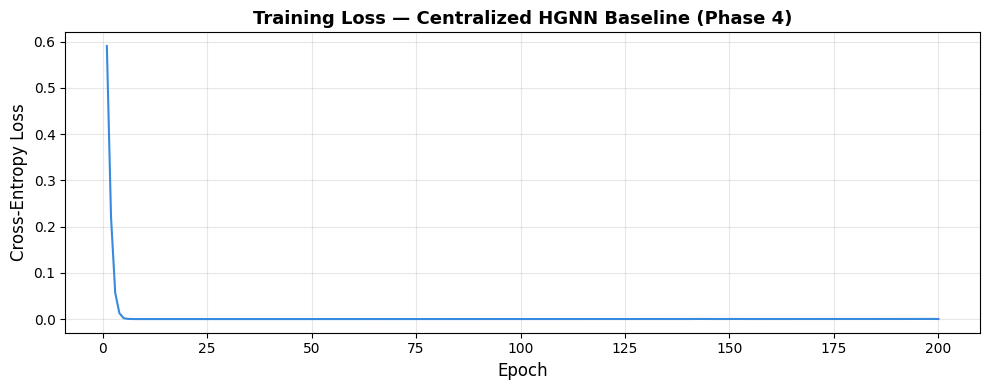

Loss plot saved. Final loss: 0.0002


In [6]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, EPOCHS + 1), loss_history, color='#378ADD', linewidth=1.5)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.title('Training Loss — Centralized HGNN Baseline (Phase 4)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.expanduser("~/Downloads/federated-hgnn-anomaly-detection/Dataset/Processed/training_loss_phase4.png"),
    dpi=150, bbox_inches='tight'
)
plt.show()
print(f"Loss plot saved. Final loss: {loss_history[-1]:.4f}")

## Cell 7 — Evaluate Model
Metrics: Accuracy, Precision, Recall, F1-score  
Evaluated on all nodes + test node separately.

In [7]:
model.eval()

with torch.no_grad():
    out   = model(x_dict, edge_index_dict)
    probs = F.softmax(out, dim=1)
    preds = out.argmax(dim=1)

y_true_all  = labels.numpy()
y_pred_all  = preds.numpy()
y_true_test = labels[test_mask].numpy()
y_pred_test = preds[test_mask].numpy()

print("=" * 50)
print("EVALUATION — ALL NODES")
print("=" * 50)
print(f"True labels:      {y_true_all.tolist()}")
print(f"Predicted labels: {y_pred_all.tolist()}")
print(f"\nAccuracy:  {accuracy_score(y_true_all, y_pred_all):.4f}")
print(f"Precision: {precision_score(y_true_all, y_pred_all, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_true_all, y_pred_all, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_true_all, y_pred_all, zero_division=0):.4f}")

print()
print("=" * 50)
print("EVALUATION — TEST NODE ONLY (User: Unknown)")
print("=" * 50)
print(f"True label:      {y_true_test.tolist()}")
print(f"Predicted label: {y_pred_test.tolist()}")

print()
print("CLASSIFICATION REPORT (all nodes):")
print(classification_report(
    y_true_all, y_pred_all,
    target_names=['Normal', 'Anomaly'],
    zero_division=0
))

print("Prediction probabilities per user node:")
user_names = ['benjamin', 'bert-jan', 'Unknown']
for i, name in enumerate(user_names):
    p_normal  = probs[i][0].item()
    p_anomaly = probs[i][1].item()
    true_lbl  = labels[i].item()
    pred_lbl  = preds[i].item()
    correct   = 'CORRECT' if true_lbl == pred_lbl else 'WRONG'
    print(f"  [{name:<10}]  P(Normal)={p_normal:.3f}  P(Anomaly)={p_anomaly:.3f}  True={true_lbl}  Pred={pred_lbl}  {correct}")

EVALUATION — ALL NODES
True labels:      [1, 1, 0]
Predicted labels: [1, 1, 1]

Accuracy:  0.6667
Precision: 0.6667
Recall:    1.0000
F1-Score:  0.8000

EVALUATION — TEST NODE ONLY (User: Unknown)
True label:      [0]
Predicted label: [1]

CLASSIFICATION REPORT (all nodes):
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00         1
     Anomaly       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3

Prediction probabilities per user node:
  [benjamin  ]  P(Normal)=0.000  P(Anomaly)=1.000  True=1  Pred=1  CORRECT
  [bert-jan  ]  P(Normal)=0.000  P(Anomaly)=1.000  True=1  Pred=1  CORRECT
  [Unknown   ]  P(Normal)=0.002  P(Anomaly)=0.998  True=0  Pred=1  WRONG


## Cell 8 — Confusion Matrix

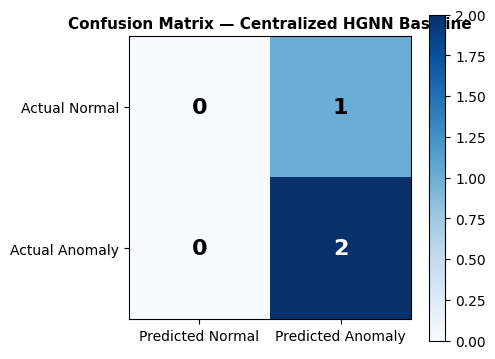

Confusion matrix saved.


In [8]:
cm = confusion_matrix(y_true_all, y_pred_all)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted Normal', 'Predicted Anomaly'], fontsize=10)
ax.set_yticklabels(['Actual Normal', 'Actual Anomaly'], fontsize=10)

for i in range(2):
    for j in range(2):
        ax.text(
            j, i, str(cm[i, j]),
            ha='center', va='center',
            color='white' if cm[i, j] > cm.max() / 2 else 'black',
            fontsize=16, fontweight='bold'
        )

ax.set_title('Confusion Matrix — Centralized HGNN Baseline', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(
    os.path.expanduser("~/Downloads/federated-hgnn-anomaly-detection/Dataset/Processed/confusion_matrix_phase4.png"),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Confusion matrix saved.")

## Cell 9 — Results Summary

In [9]:
acc  = accuracy_score(y_true_all, y_pred_all)
prec = precision_score(y_true_all, y_pred_all, zero_division=0)
rec  = recall_score(y_true_all, y_pred_all, zero_division=0)
f1   = f1_score(y_true_all, y_pred_all, zero_division=0)

print("=" * 60)
print("PHASE 4 RESULTS SUMMARY — CENTRALIZED BASELINE")
print("=" * 60)
print(f"  Model     : FederatedHGNN (HANConv, hidden=64, heads=4)")
print(f"  Optimizer : Adam  lr={LEARNING_RATE}  weight_decay={WEIGHT_DECAY}")
print(f"  Epochs    : {EPOCHS}")
print(f"  Final loss: {loss_history[-1]:.4f}")
print()
print(f"  Accuracy : {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall   : {rec:.4f}")
print(f"  F1-Score : {f1:.4f}")
print()
print("These metrics are the CENTRALIZED BASELINE.")
print("Phase 5 federated results will be compared against this.")
print("Target: federated F1 within ~5% of this baseline.")

PHASE 4 RESULTS SUMMARY — CENTRALIZED BASELINE
  Model     : FederatedHGNN (HANConv, hidden=64, heads=4)
  Optimizer : Adam  lr=0.01  weight_decay=0.0005
  Epochs    : 200
  Final loss: 0.0002

  Accuracy : 0.6667
  Precision: 0.6667
  Recall   : 1.0000
  F1-Score : 0.8000

These metrics are the CENTRALIZED BASELINE.
Phase 5 federated results will be compared against this.
Target: federated F1 within ~5% of this baseline.


## Cell 10 — Save Trained Model

In [10]:
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

torch.save(model.state_dict(), MODEL_PATH)

# Verify reload works
model_check = FederatedHGNN(
    in_channels_dict = in_channels_dict,
    hidden_channels  = 64,
    out_channels     = 2,
    metadata         = graph.metadata(),
)
model_check.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
model_check.eval()

print("Model saved and reloaded successfully.")
print(f"Saved to: {MODEL_PATH}")
print("\nPhase 4 complete. Ready for Phase 5 — Federated Learning Simulation.")

Model saved and reloaded successfully.
Saved to: /Users/philberttan/Downloads/federated-hgnn-anomaly-detection/Dataset/Processed/model_baseline.pt

Phase 4 complete. Ready for Phase 5 — Federated Learning Simulation.
